# Optimización day-ahead de costos en microrred conectada a la red
**EMS, MILP, UC+ED, scheduling**

V1: Versión en PYOMO basado en [https://gurobipy-pandas.readthedocs.io/en/stable/examples/unit-commitment.html](https://gurobipy-pandas.readthedocs.io/en/stable/examples/unit-commitment.html) y en el Ejemplo 12.15 del libro [Model Building in Mathematical Programming](https://share.google/ovWcmGq54LiyOcWm8) de H. Paul Williams (5ª edición, págs. 270-271 y 325-326).

Formulación MILP con:
- Satisfacción exacta de la demanda neta (demanda menos generación FV) por período
- Restricción de reserva operativa (15% sobre la demanda neta)
- Costos fijos por generador activo, costos marginales y costos de arranque
- Objetivo: minimizar costo total de operación

V2: El problema de Williams de despacho nacional (≈ 45 GW) redimensionado a escala de microrred (≈ 2.1 MW pico). Se reeplazaron los generadores térmicos por generadores diesel.

V3: Se pasa de una representación agregada de la demanda en 5 bloques horarios a una discretización horaria completa (24 períodos), lo cual permite capturar con mayor fidelidad las rampas de demanda, especialmente en los períodos de transición (mañana y tarde).

V4: Se agregan restricciones de rampa (ramp-up y ramp-down) para limitar la tasa de cambio de producción entre períodos consecutivos. Las restricciones se formulan de manera trivialmente satisfecha (ramp_limit = Pmax) dado que los generadores diesel tienen una dinámica de carga mucho más rápida que el paso de tiempo de 1 hora.

V5: Se incorpora un generador fotovoltaico (GFV). Los datos de irradiancia y temperatura corresponden al parque solar de la UTN FR Santa Fe, día 01/01/2019 (promedios horarios).

V6: Conexión a la red de servicio (grid-tied operation). La microrred puede importar energía del mercado (`p_buy[t]`) o exportar excedentes (`p_sell[t]`). Se agrega una variable binaria `is_buying[t]` para garantizar que importación y exportación sean mutuamente excluyentes en cada período. Los precios horarios de compra/venta se basan en el perfil dinámico de Nemati et al. (BDEW, mercado alemán), escalado a $/kWh.

## Problema: Gestión Energética de Microrred con generadores despachables, generación renovable y red

Una flota de 27 grupos generadores diesel está disponible para satisfacer la demanda eléctrica de una microrred aislada a lo largo de un día:

|       demand_hourly             |                                    |
| :-------------------------------| :--------------------------------- |
|   820, 790, 810, 800, 830, 870, |  00–05: valle nocturno             |
|  1050,1380,1575,1420,1350,1380, |  06–11: rampa matutina y mañana    |
|  1520,1480,1400,1620,1850,2050, |  12–17: tarde y rampa vespertina   |
|  2100,1980,1750,1550,1350,1100, |  18–23: pico y descenso nocturno   |

Hay tres tipos de generadores diesel disponibles, 12 pequeños (40 KW), 10 medianos (100 KW) y 5 grandes (250 KW). Cada generador opera entre un nivel mínimo (50% de capacidad nominal) y un nivel máximo. Existen costos de O&M (operación y mantenimiento) fijos, costos de combustible (modelados con curva cuadrática linealizada), costos de arranque y de apagado. Cada generador debe permanecer encendido/apagado un tiempo mínimo tras cada transición de estado. La capacidad total instalada es 2.730 kW (12×40 + 10×100 + 5×250). Considerando la reserva del 15%, la demanda máxima factible es ≈ 2.374 kW, por lo que el pico de 2.100 kW tiene margen de seguridad.

Además, se dispone de un generador fotovoltaico de 400 kWp (1000 módulos × 400 Wp). Los datos de demanda durante las 24 horas y las características de los generadores se muestran en la sección Carga de datos.

La microrred opera ahora en modo conectado (*grid-tied*). El sistema puede intercambiar energía con la red de servicio a través del Punto de Conexión Común (PCC):

- Importación (`p_buy[t]`): comprar energía de la red cuando el precio de mercado es menor que el costo marginal de generación diesel.
- Exportación (`p_sell[t]`): vender excedentes de generación FV (si los hubiera) o diesel a la red cuando el precio de venta lo justifica.

El balance de energía en cada período es ahora:

$$\sum_{g \in G} P^{\mathrm{PV}}_{g,t} + P^{\mathrm{PV}}_t + p^{\mathrm{buy}}_t - p^{\mathrm{sell}}_t = D_t \qquad \forall t \in T$$

La capacidad del transformador del PCC limita el intercambio en ambas direcciones a $\bar{P}^{\mathrm{PCC}} = 500\,\mathrm{kW}$.

La reserva operativa se mantiene sobre capacidad diesel instalada y activa, sin contar la importación de red. Esto refleja el requerimiento de que la microrred pueda operar en isla ante una desconexión de la red.

El objetivo es minimizar el costo total: costos diesel + costo neto de intercambio con la red.

In [1]:
import pyomo.environ as pe
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
import os

## Creación de Archivos de Datos

Las siguientes celdas generan los archivos CSV con los parámetros de la microrred. Si ya existen, los sobreescribe.

In [2]:
os.makedirs("data", exist_ok=True)

# ── Generadores diesel ────────────────────────────────────────────────────────
gen_lines = [
    "generator_class,num_available,min_output,max_output,cost_per_hour,startup_cost,shutdown_cost,min_up_time,min_down_time,ramp_limit,state0",
    "diesel_small,12,20.0,40.0,2.5,5.0,2.5,1,1,40.0,10",
    "diesel_med,10,50.0,100.0,5.8,12.0,6.0,1,1,100.0,9",
    "diesel_large,5,125.0,250.0,14.5,25.0,12.5,1,1,250.0,0",
]
with open("data/generators_diesel_v6.csv", "w") as f:
    f.write("\n".join(gen_lines) + "\n")

# ── Datos solares (UTN FR Santa Fe, 01/01/2019) ───────────────────────────────
solar_lines = ["hora,irradiancia,temperatura",
    "0,0.0,27.9","1,0.0,27.55","2,0.0,27.17","3,0.0,26.81",
    "4,0.0,26.48","5,0.0,26.13","6,16.0,26.36","7,89.16,27.53",
    "8,335.67,29.08","9,540.83,32.1","10,679.33,32.4","11,990.67,33.98",
    "12,773.17,35.03","13,739.0,34.73","14,196.5,30.81","15,747.17,32.45",
    "16,668.67,33.65","17,402.33,32.86","18,88.67,31.15","19,51.17,29.46",
    "20,5.17,26.98","21,0.0,28.15","22,0.0,28.67","23,0.0,28.5"]
with open("data/GFV_UTN_santafe.csv", "w") as f:
    f.write("\n".join(solar_lines) + "\n")

# ── Precios de mercado (Nemati et al., BDEW escalado a $/kWh) ────────────────
# price_buy: precio de importacion | price_sell: feed-in (siempre < price_buy)
#  Valle 00-06: buy=0.08, sell=0.04   | Pico manana 07-11: buy=0.22, sell=0.06
#  Media tarde 12-17: buy=0.15, sell=0.05 | Pico tarde 18-22: buy=0.28, sell=0.06
#  Bajada 23: buy=0.10, sell=0.04
price_profile = {
    **{h: (0.08, 0.04) for h in range(0, 7)},
    **{h: (0.22, 0.06) for h in range(7, 12)},
    **{h: (0.15, 0.05) for h in range(12, 18)},
    **{h: (0.28, 0.06) for h in range(18, 23)},
    23: (0.10, 0.04),
}
market_lines = ["hora,price_buy,price_sell"] + [f"{h},{b},{s}" for h,(b,s) in price_profile.items()]
with open("data/market_prices.csv", "w") as f:
    f.write("\n".join(market_lines) + "\n")

# ── Demanda horaria ────────────────────────────────────────────────────────────
demand_hourly = [
    820, 790, 810, 800, 830, 870,
   1050,1380,1575,1420,1350,1380,
   1520,1480,1400,1620,1850,2050,
   2100,1980,1750,1550,1350,1100,
]
import datetime
base = datetime.datetime(2024, 1, 1)
tp_lines = ["time_period,expected_demand"] + [
    f"{base + datetime.timedelta(hours=h)},{d}" for h,d in enumerate(demand_hourly)]
with open("data/time_periods_v6.csv", "w") as f:
    f.write("\n".join(tp_lines) + "\n")

print("Archivos CSV creados:")
for fn in ["generators_diesel_v6.csv","GFV_UTN_santafe.csv","market_prices.csv","time_periods_v6.csv"]:
    print(f"   data/{fn}")
print()
print("Perfil de precios (Nemati et al., BDEW):")
print(f"  {'Hora':>5} {'price_buy':>12} {'price_sell':>12}")
print("  " + "-"*32)
for h in range(24):
    b, s = price_profile[h]
    print(f"  {h:>5} {b:>12.2f} {s:>12.2f}")


Archivos CSV creados:
   data/generators_diesel_v6.csv
   data/GFV_UTN_santafe.csv
   data/market_prices.csv
   data/time_periods_v6.csv

Perfil de precios (Nemati et al., BDEW):
   Hora    price_buy   price_sell
  --------------------------------
      0         0.08         0.04
      1         0.08         0.04
      2         0.08         0.04
      3         0.08         0.04
      4         0.08         0.04
      5         0.08         0.04
      6         0.08         0.04
      7         0.22         0.06
      8         0.22         0.06
      9         0.22         0.06
     10         0.22         0.06
     11         0.22         0.06
     12         0.15         0.05
     13         0.15         0.05
     14         0.15         0.05
     15         0.15         0.05
     16         0.15         0.05
     17         0.15         0.05
     18         0.28         0.06
     19         0.28         0.06
     20         0.28         0.06
     21         0.28         0.06
    

## Modelo de Generador Fotovoltaico
**Enfoque Loyarte (2019)**

La potencia eléctrica entregada por un GFV con $N$ módulos idénticos operando en MPP (Maximum Power Point) es:

$$P_{\mathrm{PV}}[kW] = N \cdot \frac{G}{G_{\mathrm{std}}} \cdot P_{\mathrm{pico}} \cdot \bigl[1 + k_p \cdot (T_c - T_r)\bigr] \cdot \eta \cdot 10^{-3} \tag{1}$$

donde la temperatura de celda se estima a partir de la temperatura ambiente y la irradiancia incidente (modelo simplificado sin viento):

$$T_c = T + 0{,}031\,[°C \cdot m^2/W] \cdot G \tag{2}$$

**Parámetros del GFV modelado:**

| Parámetro | Símbolo | Valor | Unidad | Descripción |
|:---|:---:|---:|:---:|:---|
| Módulos instalados | $N$ | 1 000 | — | Cantidad de paneles |
| Potencia pico por módulo | $P_{\mathrm{pico}}$ | 400 | W | Módulo policristalino típico |
| Potencia nominal total | — | 400 | kWp | $N \times P_{\mathrm{pico}} \times 10^{-3}$ |
| Irradiancia estándar | $G_{\mathrm{std}}$ | 1 000 | W/m² | Condición STC fabricante |
| Temperatura de referencia | $T_r$ | 25 | °C | Condición STC fabricante |
| Coeficiente temp.-potencia | $k_p$ | −0,0045 | °C⁻¹ | Pérdida ≈ 0,45 %/°C (Si policrist.) |
| Rendimiento global | $\eta$ | 0,92 | p.u. | Incluye inversor y pérdidas BOS |

> **Nota:** Como se indica en Loyarte, las mediciones de irradiancia de la estación meteorológica se toman sobre superficie horizontal. En este ejercicio se asume, por simplicidad, que los valores corresponden directamente a $G$ (irradiancia normal a los módulos).

In [3]:
PV_N=1000; PV_Ppico=400; PV_kp=-0.0045; PV_Tr=25.0; PV_Gstd=1000.0; PV_eta=0.92

def loyarte_pv(G, T_amb):
    if G <= 0: return 0.0
    Tc = T_amb + 0.031*G
    return max(PV_N*(G/PV_Gstd)*PV_Ppico*(1+PV_kp*(Tc-PV_Tr))*PV_eta*1e-3, 0.0)

solar_data = pd.read_csv('data/GFV_UTN_santafe.csv', index_col='hora')
pv_profile = {h: round(loyarte_pv(solar_data.loc[h,'irradiancia'],
                                    solar_data.loc[h,'temperatura']), 2) for h in range(24)}

print(f'GFV: {PV_N} modulos x {PV_Ppico} Wp = {PV_N*PV_Ppico/1000:.0f} kWp')
print(f'Pico: {max(pv_profile.values()):.1f} kW  |  Energia diaria: {sum(pv_profile.values()):.1f} kWh')


GFV: 1000 modulos x 400 Wp = 400 kWp
Pico: 299.4 kW  |  Energia diaria: 2026.5 kWh


## Carga de Datos

In [4]:
generator_data = pd.read_csv('data/generators_diesel_v6.csv', index_col='generator_class')
generator_data

,num_available,min_output,max_output,cost_per_hour,startup_cost,shutdown_cost,min_up_time,min_down_time,ramp_limit,state0
generator_class,,,,,,,,,,
diesel_small,12,20.0,40.0,2.5,5.0,2.5,1,1,40.0,10
diesel_med,10,50.0,100.0,5.8,12.0,6.0,1,1,100.0,9
diesel_large,5,125.0,250.0,14.5,25.0,12.5,1,1,250.0,0


In [5]:
time_period_data = pd.read_csv('data/time_periods_v6.csv', parse_dates=['time_period'], 
    index_col='time_period')
time_period_data

,expected_demand
time_period,
2024-01-01 00:00:00,820
2024-01-01 01:00:00,790
2024-01-01 02:00:00,810
2024-01-01 03:00:00,800
2024-01-01 04:00:00,830
2024-01-01 05:00:00,870
2024-01-01 06:00:00,1050
2024-01-01 07:00:00,1380
2024-01-01 08:00:00,1575


In [6]:
solar_data_df = pd.read_csv("data/GFV_UTN_santafe.csv", index_col="hora")
solar_data_df

,irradiancia,temperatura
hora,,
0,0.00,27.90
1,0.00,27.55
2,0.00,27.17
3,0.00,26.81
4,0.00,26.48
5,0.00,26.13
6,16.00,26.36
7,89.16,27.53
8,335.67,29.08


In [7]:
market_data = pd.read_csv('data/market_prices.csv', index_col='hora')
market_data

,price_buy,price_sell
hora,,
0,0.08,0.04
1,0.08,0.04
2,0.08,0.04
3,0.08,0.04
4,0.08,0.04
5,0.08,0.04
6,0.08,0.04
7,0.22,0.06
8,0.22,0.06


## Conjuntos

In [8]:
GENERATORS   = list(generator_data.index)
TIME_PERIODS = list(time_period_data.index)
T            = list(range(len(TIME_PERIODS)))
print(f'Clases de generadores : {GENERATORS}')
print(f'Numero de periodos    : {len(T)}')

Clases de generadores : ['diesel_small', 'diesel_med', 'diesel_large']
Numero de periodos    : 24


## Parámetros

Los parámetros del modelo se construyen como diccionarios Python a partir de los DataFrames cargados.

- $n_g$: unidades disponibles de la clase $g$
- $P^{\min}_g$, $P^{\max}_g$: límites de producción por unidad [kW]
- $c_g$: costo fijo de O&M por hora por unidad activa [$/h]
- $s^u_g$: costo de arranque [$]
- $s^d_g$: costo de apagado [$]
- $\tau^{\mathrm{up}}_g$, $\tau^{\mathrm{dn}}_g$: tiempos mínimos de encendido/apagado [períodos]
- $a^0_g$: estado inicial (unidades activas antes del primer período)
- $P^{\mathrm{PV}}_t$: potencia fotovoltaica en el período $t$ [kW] — calculada con modelo Loyarte
- $D_t$: demanda bruta esperada en el período $t$ [kW]
- $D^{\mathrm{net}}_t = D_t - P^{\mathrm{PV}}_t$: demanda neta a cubrir por diesel en $t$ [kW]
- $\bar{D}^{\mathrm{net}}_t = 1{,}15 \cdot D^{\mathrm{net}}_t$: capacidad activa mínima requerida en $t$ [kW]
- $S_j^g$, $s_j^g$: pendiente e intercepto del segmento $j$ de la curva de combustible de la clase $g$

En esta versión se agregan:
- $\pi^{\mathrm{buy}}_t$: precio de importación desde la red [$/kWh]
- $\pi^{\mathrm{sell}}_t$: precio de exportación hacia la red [$/kWh]
- $\bar{P}^{\mathrm{PCC}}$: capacidad máxima de intercambio en el PCC [kW]
- $M$: constante Big-M para la restricción de no-simultaneidad [kW]

In [9]:
# ── Parámetros por clase de generador ───────────────────────────────────────
num_available = generator_data['num_available'].to_dict()
min_output    = generator_data['min_output'].to_dict()
max_output    = generator_data['max_output'].to_dict()
cost_per_hour = generator_data['cost_per_hour'].to_dict()
startup_cost  = generator_data['startup_cost'].to_dict()
shutdown_cost = generator_data['shutdown_cost'].to_dict()
min_up_time   = generator_data['min_up_time'].to_dict()
min_down_time = generator_data['min_down_time'].to_dict()
ramp_limit    = generator_data['ramp_limit'].to_dict()
state0        = generator_data['state0'].to_dict()

# ── Parámetros por período (indexados por entero) ────────────────────────────
expected_demand  = {i: time_period_data['expected_demand'].iloc[i] for i in T}

pv_output        = {i: pv_profile[i] for i in T}
price_buy        = {i: market_data.loc[i, 'price_buy']  for i in T}
price_sell       = {i: market_data.loc[i, 'price_sell'] for i in T}

PCC_LIMIT = 500.0   # kW
BIG_M     = PCC_LIMIT

# Demanda neta = demanda bruta − generación PV
net_demand              = {i: expected_demand[i] - pv_output[i] for i in T}

# Reserva: 15% sobre demanda bruta, solo capacidad diesel (reserva de isla)
minimum_active_capacity = {i: round(expected_demand[i]*1.15, 2) for i in T}

## Linealización de la Curva de Costo de Combustible
### Enfoque Parisio (2014)

Dado que los MILP son computacionalmente más eficientes que los MIQP, la función de costo de combustible de un generador diesel:

$$f(P) = a P^2 + b P \quad [\text{\$/h}]$$

se aproxima por el máximo de funciones afines sin introducir variables binarias adicionales:

$$f(P) \approx \sigma = \max_{j=1,\dots,n}\{S_j P + s_j\}$$

donde los coeficientes de cada segmento $j$ se obtienen evaluando la tangente de $f$ en el punto de soporte $P_j$:

$$S_j = f'(P_j) = 2aP_j + b \qquad s_j = f(P_j) - S_j P_j = -aP_j^2$$

Extensión a clases de generadores (formulación agregada): si hay $n_{g,t}$ unidades activas de la clase $g$ produciendo $P^{\mathrm{D}}_{g,t}$ kW en total, el costo de combustible agregado es:

$$n_{g,t} \cdot f\!\left(\frac{P^{\mathrm{D}}_{g,t}}{n_{g,t}}\right) = a\frac{{P^{\mathrm{D}}_{g,t}}^2}{n_{g,t}} + b\, P^{\mathrm{D}}_{g,t}$$

Con la aproximación lineal tangente en cada punto de soporte, esto se convierte en el conjunto de restricciones lineales:

$$\sigma_{g,t} \geq S_j^{g} \cdot P^{\mathrm{D}}_{g,t} + s_j^{g} \cdot n_{g,t} \qquad \forall j = 1, \dots, n_{\mathrm{seg}}$$

Esta formulación es lineal porque $S_j^{g}$ y $s_j^{g}$ son constantes, $P^{\mathrm{D}}_{g,t}$ es continua y $n_{g,t}$ es entera.

Se definen los coeficientes cuadráticos de la función de costo de combustible por unidad:

$$f_g(P) = a_g P^2 + b_g P \quad [\text{\$/h}]$$

y se calculan los segmentos lineales evaluando las tangentes en $n_{\mathrm{seg}} = 3$ puntos de soporte equidistantes entre $P^{\min}_g$ y $P^{\max}_g$.

Los coeficientes (Tabla 2.1 de Nemati) $a$ en $ml/kW^{2}h$ y $b$ en $l/kWh$ se multiplicaron por un precio de combustible estimado de $1.2 $/l$.


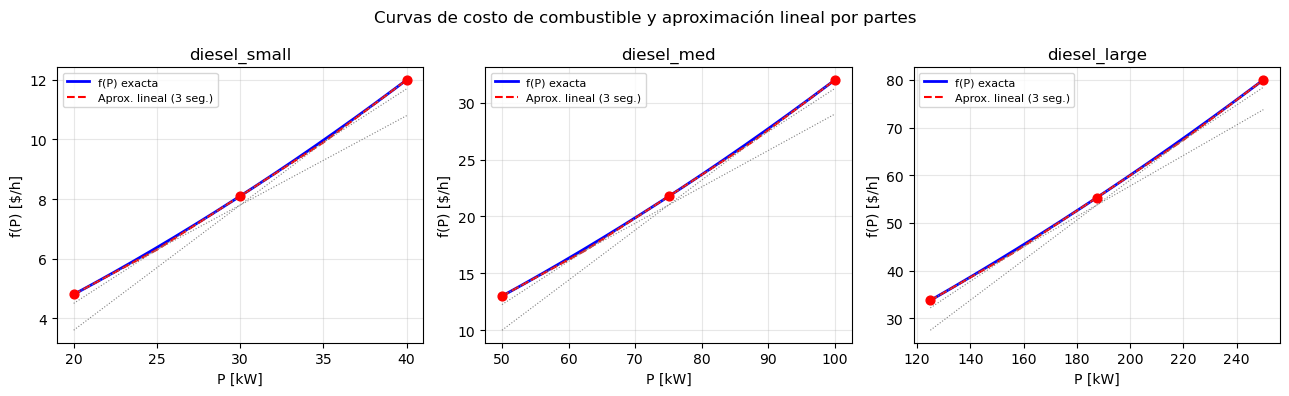


Segmentos lineales de la curva de combustible:
Clase           Seg   P_soporte (kW)   Pendiente S_j   Intercepto s_j
--------------------------------------------------------------------
diesel_small      0             20.0         0.30000          -1.2000
diesel_small      1             30.0         0.36000          -2.7000
diesel_small      2             40.0         0.42000          -4.8000

diesel_med        0             50.0         0.32000          -3.0000
diesel_med        1             75.0         0.38000          -6.7500
diesel_med        2            100.0         0.44000         -12.0000

diesel_large      0            125.0         0.32000          -6.2500
diesel_large      1            187.5         0.37000         -14.0625
diesel_large      2            250.0         0.42000         -25.0000



In [10]:
quad_params = {
    'diesel_small': {'a': 0.003,   'b': 0.18},
    'diesel_med':   {'a': 0.0012,  'b': 0.20},
    'diesel_large': {'a': 0.0004,  'b': 0.22},
}

N_SEG = 3

lin_segments = {}
for g in GENERATORS:
    a  = quad_params[g]['a']
    b  = quad_params[g]['b']
    support_points = np.linspace(min_output[g], max_output[g], N_SEG)
    slopes     = [2 * a * pj + b for pj in support_points]
    intercepts = [-a * pj**2      for pj in support_points]
    lin_segments[g] = {'slopes': slopes, 'intercepts': intercepts, 'support': support_points}

SEGMENTS = list(range(N_SEG))

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
fig.suptitle("Curvas de costo de combustible y aproximación lineal por partes", fontsize=12)

for ax, g in zip(axes, GENERATORS):
    a = quad_params[g]['a']; b = quad_params[g]['b']
    P = np.linspace(min_output[g], max_output[g], 200)
    f_exact  = a * P**2 + b * P
    f_approx = np.max(np.array([lin_segments[g]['slopes'][j]*P + lin_segments[g]['intercepts'][j]
                                 for j in SEGMENTS]), axis=0)
    ax.plot(P, f_exact,  'b-',  lw=2,   label='f(P) exacta')
    ax.plot(P, f_approx, 'r--', lw=1.5, label='Aprox. lineal (3 seg.)')
    for j in SEGMENTS:
        ax.plot(P, lin_segments[g]['slopes'][j]*P + lin_segments[g]['intercepts'][j],
                'gray', lw=0.8, ls=':')
    ax.scatter(lin_segments[g]['support'],
               [a*pj**2+b*pj for pj in lin_segments[g]['support']],
               color='red', zorder=5, s=40)
    ax.set_xlabel("P [kW]"); ax.set_ylabel("f(P) [$/h]")
    ax.set_title(g); ax.legend(fontsize=8); ax.grid(alpha=0.3)

plt.tight_layout(); plt.show()

print("\nSegmentos lineales de la curva de combustible:")
print(f"{'Clase':<14} {'Seg':>4} {'P_soporte (kW)':>16} {'Pendiente S_j':>15} {'Intercepto s_j':>16}")
print("-" * 68)
for g in GENERATORS:
    for j in SEGMENTS:
        print(f"{g:<14} {j:>4} {lin_segments[g]['support'][j]:>16.1f} {lin_segments[g]['slopes'][j]:>15.5f} {lin_segments[g]['intercepts'][j]:>16.4f}")
    print()

## Perfil de Generación Fotovoltaica

Visualización del perfil horario calculado con el modelo Loyarte, junto con los datos de entrada (irradiancia y temperatura de celda).

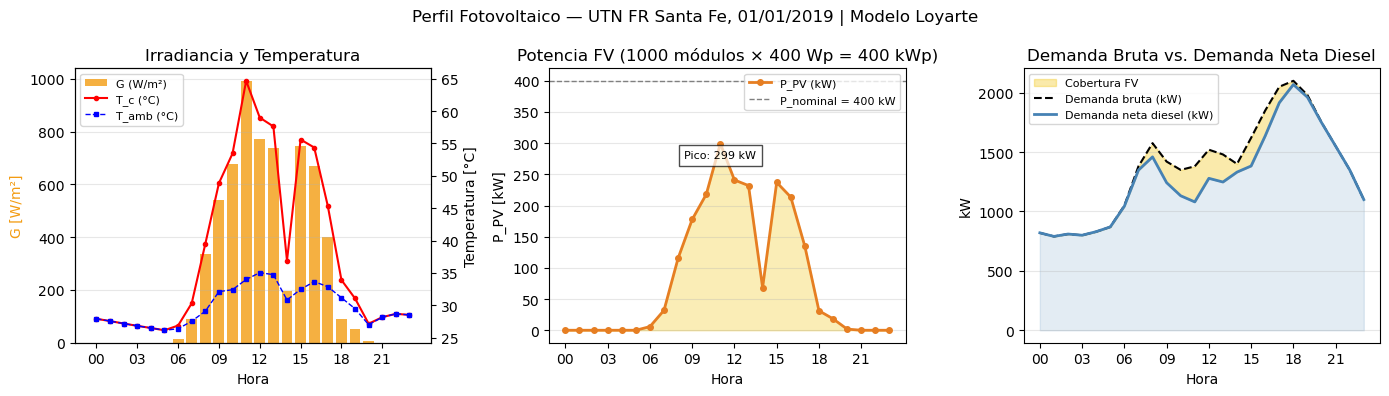

Energía FV total     : 2026.5 kWh/día
Energía demanda total: 32825 kWh/día
Fracción FV          : 6.2%
Reducción pico diesel: 31.3 kW → demanda neta máx = 2069 kW


In [11]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
fig.suptitle("Perfil Fotovoltaico — UTN FR Santa Fe, 01/01/2019 | Modelo Loyarte", fontsize=12)

hours_x = list(range(24))
irrad_vals = [solar_data_df.loc[h,'irradiancia'] for h in hours_x]
temp_vals  = [solar_data_df.loc[h,'temperatura'] for h in hours_x]
tc_vals    = [solar_data_df.loc[h,'temperatura'] + 0.031*solar_data_df.loc[h,'irradiancia'] for h in hours_x]
pv_vals    = [pv_profile[h] for h in hours_x]
demand_bruta = [expected_demand[h] for h in hours_x]
demand_neta  = [net_demand[h] for h in hours_x]

# Irradiancia y temperatura de celda
ax1 = axes[0]
ax1.bar(hours_x, irrad_vals, color='#f39c12', alpha=0.8, label='G (W/m²)', width=0.8)
ax1.set_xlabel('Hora'); ax1.set_ylabel('G [W/m²]', color='#f39c12')
ax1b = ax1.twinx()
ax1b.plot(hours_x, tc_vals, 'r-o', ms=3, lw=1.5, label='T_c (°C)')
ax1b.plot(hours_x, temp_vals, 'b--s', ms=3, lw=1, label='T_amb (°C)')
ax1b.set_ylabel('Temperatura [°C]')
lines1, lbl1 = ax1.get_legend_handles_labels()
lines2, lbl2 = ax1b.get_legend_handles_labels()
ax1.legend(lines1+lines2, lbl1+lbl2, fontsize=8, loc='upper left')
ax1.set_title('Irradiancia y Temperatura')
ax1.set_xticks(range(0,24,3)); ax1.set_xticklabels([f'{h:02d}' for h in range(0,24,3)])
ax1.grid(alpha=0.3, axis='y')

# Potencia PV
ax2 = axes[1]
ax2.fill_between(hours_x, pv_vals, alpha=0.3, color='#f1c40f')
ax2.plot(hours_x, pv_vals, 'o-', color='#e67e22', lw=2, ms=4, label='P_PV (kW)')
ax2.axhline(PV_N*PV_Ppico/1000, color='gray', lw=1, ls='--',
            label=f'P_nominal = {PV_N*PV_Ppico/1000:.0f} kW')
ax2.set_xlabel('Hora'); ax2.set_ylabel('P_PV [kW]')
ax2.set_title(f'Potencia FV ({PV_N} módulos × {PV_Ppico} Wp = {PV_N*PV_Ppico/1000:.0f} kWp)')
ax2.set_xticks(range(0,24,3)); ax2.set_xticklabels([f'{h:02d}' for h in range(0,24,3)])
ax2.legend(fontsize=8); ax2.grid(alpha=0.3, axis='y')
ax2.text(11, max(pv_vals)*0.92, f'Pico: {max(pv_vals):.0f} kW', ha='center', fontsize=8,
         bbox=dict(facecolor='white', alpha=0.7))

# Demanda bruta vs neta
ax3 = axes[2]
ax3.fill_between(hours_x, demand_bruta, demand_neta, alpha=0.35, color='#f1c40f', label='Cobertura FV')
ax3.fill_between(hours_x, demand_neta, alpha=0.15, color='steelblue')
ax3.plot(hours_x, demand_bruta, 'k--', lw=1.5, label='Demanda bruta (kW)')
ax3.plot(hours_x, demand_neta,  'steelblue', lw=2, label='Demanda neta diesel (kW)')
ax3.set_xlabel('Hora'); ax3.set_ylabel('kW')
ax3.set_title('Demanda Bruta vs. Demanda Neta Diesel')
ax3.set_xticks(range(0,24,3)); ax3.set_xticklabels([f'{h:02d}' for h in range(0,24,3)])
ax3.legend(fontsize=8); ax3.grid(alpha=0.3, axis='y')

plt.tight_layout(); plt.show()

total_pv_energy  = sum(pv_vals)
total_bruta_energy = sum(demand_bruta)
print(f"Energía FV total     : {total_pv_energy:.1f} kWh/día")
print(f"Energía demanda total: {total_bruta_energy:.0f} kWh/día")
print(f"Fracción FV          : {100*total_pv_energy/total_bruta_energy:.1f}%")
print(f"Reducción pico diesel: {max(demand_bruta)-max(demand_neta):.1f} kW → demanda neta máx = {max(demand_neta):.0f} kW")

## Perfil de Precios de Mercado y Generación Fotovoltaica

Visualización comparativa del perfil de precios horarios (Nemati et al., BDEW) y la generación fotovoltaica disponible. La línea de referencia de costo marginal diesel (~$0.22/kWh) indica cuándo la red es competitiva.

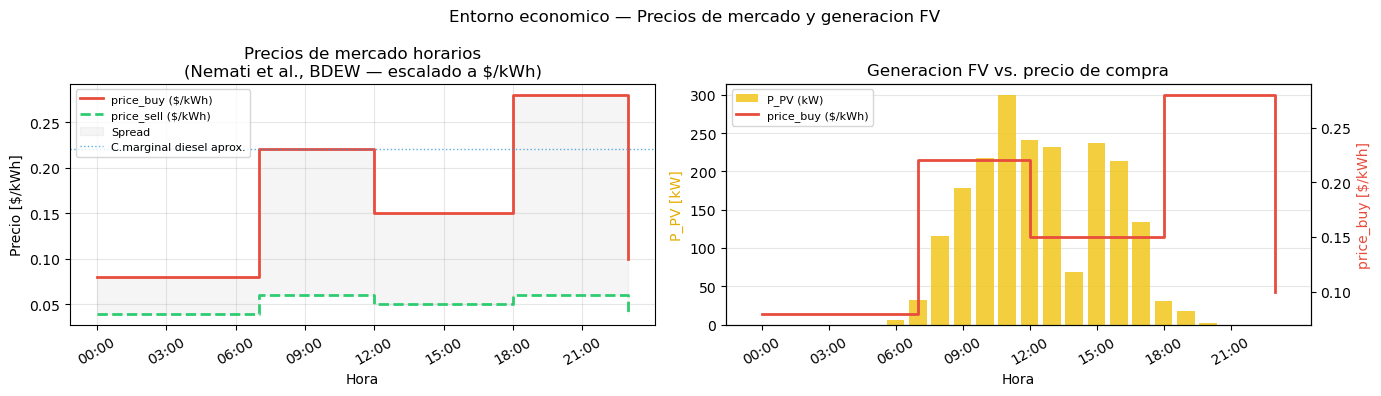

Analisis previo:
  price_buy min/max: $0.08 / $0.28 /kWh
  Horas con price_buy < costo marginal diesel: [0, 1, 2, 3, 4, 5, 6, 12, 13, 14, 15, 16, 17, 23]
  -> El solver deberia importar preferentemente en esas horas


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fig.suptitle('Entorno economico — Precios de mercado y generacion FV', fontsize=12)

hours_x  = list(range(24))
buy_vals  = [price_buy[i]  for i in T]
sell_vals = [price_sell[i] for i in T]
pv_vals   = [pv_output[i]  for i in T]

ax1 = axes[0]
ax1.step(hours_x, buy_vals,  where='post', color='#e74c3c', lw=2,   label='price_buy ($/kWh)')
ax1.step(hours_x, sell_vals, where='post', color='#2ecc71', lw=2, ls='--', label='price_sell ($/kWh)')
ax1.fill_between(hours_x, sell_vals, buy_vals, step='post', alpha=0.08, color='gray', label='Spread')
ax1.axhline(0.22, color='#3498db', lw=1, ls=':', alpha=0.8, label='C.marginal diesel aprox.')
ax1.set_xlabel('Hora'); ax1.set_ylabel('Precio [$/kWh]')
ax1.set_title('Precios de mercado horarios\n(Nemati et al., BDEW — escalado a $/kWh)')
ax1.set_xticks(range(0,24,3)); ax1.set_xticklabels([f'{h:02d}:00' for h in range(0,24,3)], rotation=30)
ax1.legend(loc='upper left',fontsize=8); ax1.grid(alpha=0.3)

ax2 = axes[1]
ax2b = ax2.twinx()
ax2.bar(hours_x, pv_vals, color='#f1c40f', alpha=0.8, width=0.8, label='P_PV (kW)', zorder=2)
ax2b.step(hours_x, buy_vals, where='post', color='#e74c3c', lw=2, label='price_buy ($/kWh)', zorder=3)
ax2.set_xlabel('Hora'); ax2.set_ylabel('P_PV [kW]', color='#e6ac00')
ax2b.set_ylabel('price_buy [$/kWh]', color='#e74c3c')
ax2.set_title('Generacion FV vs. precio de compra')
ax2.set_xticks(range(0,24,3)); ax2.set_xticklabels([f'{h:02d}:00' for h in range(0,24,3)], rotation=30)
lines1,lbl1 = ax2.get_legend_handles_labels()
lines2,lbl2 = ax2b.get_legend_handles_labels()
ax2.legend(lines1+lines2, lbl1+lbl2, loc='upper left', fontsize=8)
ax2.grid(alpha=0.3, axis='y')
plt.tight_layout(); plt.show()

print('Analisis previo:')
print(f'  price_buy min/max: ${min(buy_vals):.2f} / ${max(buy_vals):.2f} /kWh')
horas_baratas = [i for i in T if price_buy[i] < 0.22]
print(f'  Horas con price_buy < costo marginal diesel: {horas_baratas}')
print(f'  -> El solver deberia importar preferentemente en esas horas')

## Construcción del Modelo Pyomo

In [13]:
model = pe.ConcreteModel(name='UC_Microgrid_GridTied_V6')

## Conjuntos del Modelo

In [14]:
model.G = pe.Set(initialize=GENERATORS, doc='Clases de generadores diesel')
model.T = pe.Set(initialize=T, ordered=True, doc='Periodos de tiempo')
model.J = pe.Set(initialize=SEGMENTS, doc='Segmentos de linealizacion combustible')

## Parámetros del Modelo

In [15]:
model.num_available           = pe.Param(model.G, initialize=num_available)
model.min_output              = pe.Param(model.G, initialize=min_output)
model.max_output              = pe.Param(model.G, initialize=max_output)
model.cost_per_hour           = pe.Param(model.G, initialize=cost_per_hour)
model.startup_cost            = pe.Param(model.G, initialize=startup_cost)
model.shutdown_cost           = pe.Param(model.G, initialize=shutdown_cost)
model.min_up_time             = pe.Param(model.G, initialize=min_up_time)
model.min_down_time           = pe.Param(model.G, initialize=min_down_time)
model.ramp_limit              = pe.Param(model.G, initialize=ramp_limit)
model.state0                  = pe.Param(model.G, initialize=state0)
model.expected_demand         = pe.Param(model.T, initialize=expected_demand,        doc='Demanda bruta [kW]')
model.pv_output               = pe.Param(model.T, initialize=pv_output,              doc='Generacion FV [kW]')
model.minimum_active_capacity = pe.Param(model.T, initialize=minimum_active_capacity, doc='1.15 x D_bruta [kW]')
model.price_buy               = pe.Param(model.T, initialize=price_buy,              doc='Precio importacion [$/kWh]')
model.price_sell              = pe.Param(model.T, initialize=price_sell,             doc='Precio exportacion [$/kWh]')
model.pcc_limit               = pe.Param(initialize=PCC_LIMIT,                       doc='Limite PCC [kW]')
model.big_m                   = pe.Param(initialize=BIG_M,                           doc='Big-M [kW]')

slope_data     = {(g,j): lin_segments[g]['slopes'][j]     for g in GENERATORS for j in SEGMENTS}
intercept_data = {(g,j): lin_segments[g]['intercepts'][j] for g in GENERATORS for j in SEGMENTS}
model.lin_slope     = pe.Param(model.G, model.J, initialize=slope_data)
model.lin_intercept = pe.Param(model.G, model.J, initialize=intercept_data)

## Variables de Decisión

| Variable | Índices | Tipo | Descripción |
|:---|:---:|:---:|:---|
| $P^{\mathrm{D}}_{g,t}$ (`output`) | $g,t$ | Continua ≥ 0 | Producción total diesel clase $g$ [kW] |
| $\sigma_{g,t}$ (`sigma`) | $g,t$ | Continua ≥ 0 | Costo combustible — linealización Parisio [$/h] |
| $n_{g,t}$ (`num_active`) | $g,t$ | Entera ∈ [0, $n_g$] | Generadores activos |
| $u_{g,t}$ (`num_startup`) | $g,t$ | Entera ≥ 0 | Arranques en $t$ |
| $v_{g,t}$ (`num_shutdown`) | $g,t$ | Entera ≥ 0 | Apagados en $t$ |
| $p^{\mathrm{buy}}_t$ (`p_buy`) | $t$ | Continua ∈ [0, 500] | Importación de red [kW] |
| $p^{\mathrm{sell}}_t$ (`p_sell`) | $t$ | Continua ∈ [0, 500] | Exportación a red [kW] |
| $\delta_t$ (`is_buying`) | $t$ | Binaria {0,1} | 1 si importa, 0 si exporta o neutro |

La restricción Big-M garantiza no-simultaneidad:
$$p^{\mathrm{buy}}_t \leq \bar{P}^{PCC} \cdot \delta_t \qquad p^{\mathrm{sell}}_t \leq \bar{P}^{PCC} \cdot (1-\delta_t)$$

## Definición de Variables

In [16]:
model.output = pe.Var(model.G, model.T, within=pe.NonNegativeReals, doc='Produccion diesel [kW]')
model.sigma  = pe.Var(model.G, model.T, within=pe.NonNegativeReals, doc='Costo combustible [$/h]')

def num_active_bounds(m, g, t): return (0, m.num_available[g])
model.num_active   = pe.Var(model.G, model.T, within=pe.NonNegativeIntegers,
                             bounds=num_active_bounds, doc='Generadores activos')
model.num_startup  = pe.Var(model.G, model.T, within=pe.NonNegativeIntegers, doc='Arranques')
model.num_shutdown = pe.Var(model.G, model.T, within=pe.NonNegativeIntegers, doc='Apagados')

# ── Variables de intercambio con la red (nuevas en V6) ───────────────────────
def pcc_bounds(m, t): return (0, m.pcc_limit)
model.p_buy     = pe.Var(model.T, within=pe.NonNegativeReals, bounds=pcc_bounds,
                          doc='Importacion de red [kW]')
model.p_sell    = pe.Var(model.T, within=pe.NonNegativeReals, bounds=pcc_bounds,
                          doc='Exportacion a red [kW]')
model.is_buying = pe.Var(model.T, within=pe.Binary,
                          doc='Binaria: 1=importando, 0=exportando o neutro')


## Restricciones

### 1. Balance de Energía (modificado en V6)

El balance incluye la generación FV y el intercambio con la red. Se usa la demanda bruta (no la neta como en V5) para que la interacción con la red sea explícita en la restricción:

$$\sum_{g \in G} P^{\mathrm{D}}_{g,t} + P^{\mathrm{PV}}_t + p^{\mathrm{buy}}_t - p^{\mathrm{sell}}_t = D_t \qquad \forall t \in T$$

In [17]:
def demand_rule(m, t):
    return (sum(m.output[g,t] for g in m.G)
            + m.pv_output[t]
            + m.p_buy[t]
            - m.p_sell[t]
            == m.expected_demand[t])

model.demand_constraint = pe.Constraint(model.T, rule=demand_rule,
    doc='Balance: diesel + PV + p_buy - p_sell = demanda bruta')

### 2. Reserva Operativa (basada en diesel, no en red)

La capacidad activa diesel debe garantizar el 15% de reserva sobre la demanda bruta, sin contar la importación de red. Modela el requerimiento de operación en isla:

$$\sum_{g \in G} P^{\max}_g \cdot n_{g,t} \geq 1{,}15 \cdot D_t \qquad \forall t \in T$$

In [18]:
def reserve_rule(m, t):
    return sum(m.max_output[g]*m.num_active[g,t] for g in m.G) >= m.minimum_active_capacity[t]
model.reserve_constraint = pe.Constraint(model.T, rule=reserve_rule,
    doc='Capacidad activa diesel >= 1.15 x D_bruta (reserva isla)')


### 3. Límites de Producción Diesel

$$P^{\min}_g \cdot n_{g,t} \leq P^{\mathrm{D}}_{g,t} \leq P^{\max}_g \cdot n_{g,t} \qquad \forall g \in G, t \in T$$

In [19]:
def output_lower_rule(m,g,t): return m.output[g,t] >= m.min_output[g]*m.num_active[g,t]
model.output_lower = pe.Constraint(model.G, model.T, rule=output_lower_rule)
def output_upper_rule(m,g,t): return m.output[g,t] <= m.max_output[g]*m.num_active[g,t]
model.output_upper = pe.Constraint(model.G, model.T, rule=output_upper_rule)

### 4. Balance de Estado: Arranques

La variable $u_{g,t}$ captura el incremento neto de unidades activas entre períodos.

**Períodos $t > t_0$:**
$$u_{g,t} \geq n_{g,t} - n_{g,t-1} \qquad \forall g \in G,\; t \in T \setminus \{t_0\}$$

**Primer período $t_0$:**
$$u_{g,t_0} \geq n_{g,t_0} - a^0_g \qquad \forall g \in G$$

In [20]:
def startup_rule(m,g,t):
    if t==m.T.first(): return pe.Constraint.Skip
    return m.num_startup[g,t] >= m.num_active[g,t] - m.num_active[g,m.T.prev(t)]
model.startup_constraint = pe.Constraint(model.G, model.T, rule=startup_rule)

def initial_startup_rule(m,g):
    return m.num_startup[g,m.T.first()] >= m.num_active[g,m.T.first()] - m.state0[g]
model.initial_startup = pe.Constraint(model.G, rule=initial_startup_rule)

### 5. Balance de Estado: Apagados

Simétricamente, $v_{g,t}$ captura el decremento neto de unidades activas.

**Períodos $t > t_0$:**
$$v_{g,t} \geq n_{g,t-1} - n_{g,t} \qquad \forall g \in G,\; t \in T \setminus \{t_0\}$$

**Primer período $t_0$:**
$$v_{g,t_0} \geq a^0_g - n_{g,t_0} \qquad \forall g \in G$$

In [21]:
def shutdown_rule(m,g,t):
    if t==m.T.first(): return pe.Constraint.Skip
    return m.num_shutdown[g,t] >= m.num_active[g,m.T.prev(t)] - m.num_active[g,t]
model.shutdown_constraint = pe.Constraint(model.G, model.T, rule=shutdown_rule)

def initial_shutdown_rule(m,g):
    return m.num_shutdown[g,m.T.first()] >= m.state0[g] - m.num_active[g,m.T.first()]
model.initial_shutdown = pe.Constraint(model.G, rule=initial_shutdown_rule)


### 6. Tiempo Mínimo de Encendido (Min Up-Time)

$$\sum_{k=t-\tau^{\mathrm{up}}_g+1}^{t} u_{g,k} \leq n_{g,t} \qquad \forall g \in G,\; t \geq \tau^{\mathrm{up}}_g$$

In [22]:
def min_up_time_rule(m,g,t):
    mut = int(pe.value(m.min_up_time[g]))
    if mut<=1: return pe.Constraint.Skip
    t_list = list(m.T)
    if t<mut-1: return pe.Constraint.Skip
    window = [t_list[k] for k in range(t-mut+1,t+1) if k>=0]
    return sum(m.num_startup[g,tau] for tau in window) <= m.num_active[g,t_list[t]]
model.min_up_time_constraint = pe.Constraint(model.G, model.T, rule=min_up_time_rule)

### 7. Tiempo Mínimo de Apagado (Min Down-Time)

$$\sum_{k=t-\tau^{\mathrm{dn}}_g+1}^{t} v_{g,k} \leq n_g - n_{g,t} \qquad \forall g \in G,\; t \geq \tau^{\mathrm{dn}}_g$$

In [23]:
def min_down_time_rule(m,g,t):
    mdt = int(pe.value(m.min_down_time[g]))
    if mdt<=1: return pe.Constraint.Skip
    t_list = list(m.T)
    if t<mdt-1: return pe.Constraint.Skip
    window = [t_list[k] for k in range(t-mdt+1,t+1) if k>=0]
    return sum(m.num_shutdown[g,tau] for tau in window) <= m.num_available[g]-m.num_active[g,t_list[t]]
model.min_down_time_constraint = pe.Constraint(model.G, model.T, rule=min_down_time_rule)

### 8. Linealización de la Curva de Combustible (Enfoque Parisio)

Para cada segmento $j$ de la aproximación lineal, se impone que $\sigma_{g,t}$ sea mayor o igual al costo de combustible calculado con la recta tangente en el punto de soporte $j$:

$$\sigma_{g,t} \geq S_j^g \cdot P^{\mathrm{D}}_{g,t} + s_j^g \cdot n_{g,t} \qquad \forall g \in G,\; t \in T,\; j \in J$$

Como $\sigma_{g,t}$ aparece con signo positivo en el objetivo (minimización), el solver lo fijará en el máximo de las rectas tangentes, reproduciendo la envolvente convexa de la curva cuadrática.

In [24]:
def fuel_cost_linearization_rule(m,g,t,j):
    return m.sigma[g,t] >= m.lin_slope[g,j]*m.output[g,t] + m.lin_intercept[g,j]*m.num_active[g,t]
model.fuel_cost_linearization = pe.Constraint(model.G, model.T, model.J,
                                               rule=fuel_cost_linearization_rule)

### 9. Restricciones de Rampa (Ramp-Up y Ramp-Down)

Los generadores diesel no pueden cambiar su producción de forma instantánea. Se limita la tasa de cambio de producción entre períodos consecutivos para proteger los motores y reflejar la realidad operativa.

La formulación correcta para clases agregadas de generadores debe descontar el efecto de arranques y apagados — un generador que arranca en $t$ puede contribuir hasta su máximo sin violar la rampa, y uno que se apaga no penaliza la bajada:

Rampa de subida:
$$P^{\mathrm{D}}_{g,t} - P^{\mathrm{D}}_{g,t-1} \leq R_g \cdot n_{g,t-1} + P^{\max}_g \cdot u_{g,t} \qquad \forall g \in G,\; t \in T \setminus \{t_0\}$$

Rampa de bajada:
$$P^{\mathrm{D}}_{g,t-1} - P^{\mathrm{D}}_{g,t} \leq R_g \cdot n_{g,t} + P^{\max}_g \cdot v_{g,t} \qquad \forall g \in G,\; t \in T \setminus \{t_0\}$$

Donde $R_g$ es el límite de rampa [kW/h] de la clase $g$ (50% de $P^{\max}_g$). Los términos $P^{\max}_g \cdot u_{g,t}$ y $P^{\max}_g \cdot v_{g,t}$ permiten que las unidades recién arrancadas/apagadas contribuyan libremente, evitando que la restricción sea artificialmente activa durante transiciones de encendido/apagado.

> Nota sobre la formulación: una versión simplificada usaría $R_g \cdot n_{g,t}$ en ambas restricciones, pero sobrerestringiría los casos donde el número de activos cambia entre períodos. La formulación implementada sigue el enfoque de Morales-España et al. y es consistente con Parisio para modelos agregados.


In [25]:
def ramp_up_rule(m,g,t):
    if t==m.T.first(): return pe.Constraint.Skip
    return (m.output[g,t] - m.output[g,m.T.prev(t)]
            <= m.ramp_limit[g]*m.num_active[g,m.T.prev(t)] + m.max_output[g]*m.num_startup[g,t])
model.ramp_up_constraint = pe.Constraint(model.G, model.T, rule=ramp_up_rule)

def ramp_down_rule(m,g,t):
    if t==m.T.first(): return pe.Constraint.Skip
    return (m.output[g,m.T.prev(t)] - m.output[g,t]
            <= m.ramp_limit[g]*m.num_active[g,t] + m.max_output[g]*m.num_shutdown[g,t])
model.ramp_down_constraint = pe.Constraint(model.G, model.T, rule=ramp_down_rule)

### 10. No-Simultaneidad Importación/Exportación — Big-M (nuevas en V6)

Se usa la formulación Big-M con la binaria `is_buying[t]`:

\begin{align}
&p^{\mathrm{buy}}_t \leq \bar{P}^{PCC} \cdot \delta_t \quad \forall t \tag{10a}\\
&p^{\mathrm{sell}}_t \leq \bar{P}^{PCC} \cdot (1-\delta_t) \quad \forall t \tag{10b}
\end{align}

Cuando $\delta_t=1$: se permite importar hasta $\bar{P}^{PCC}$, exportación forzada a 0.  
Cuando $\delta_t=0$: se permite exportar hasta $\bar{P}^{PCC}$, importación forzada a 0.

> **Nota:** dado que $\pi^{\mathrm{sell}}_t < \pi^{\mathrm{buy}}_t$ siempre, no existe incentivo económico para comprar y vender simultáneamente. La restricción Big-M es de todas formas importante para robustez numérica y para evitar soluciones degeneradas.

In [26]:
def no_buy_sell_buy_rule(m, t):
    return m.p_buy[t] <= m.big_m * m.is_buying[t]
model.no_buy_sell_buy = pe.Constraint(model.T, rule=no_buy_sell_buy_rule,
    doc='p_buy <= PCC_limit * is_buying')

def no_buy_sell_sell_rule(m, t):
    return m.p_sell[t] <= m.big_m * (1 - m.is_buying[t])
model.no_buy_sell_sell = pe.Constraint(model.T, rule=no_buy_sell_sell_rule,
    doc='p_sell <= PCC_limit * (1-is_buying)')

print('Restricciones de no-simultaneidad:')
print('  p_buy[t]  <= PCC_limit x is_buying[t]')
print('  p_sell[t] <= PCC_limit x (1 - is_buying[t])')


Restricciones de no-simultaneidad:
  p_buy[t]  <= PCC_limit x is_buying[t]
  p_sell[t] <= PCC_limit x (1 - is_buying[t])


## Función Objetivo

Se minimiza el costo total de operación diesel más el costo neto de intercambio con la red:

$$\min \sum_{g,t} \left[ c_g n_{g,t} + \sigma_{g,t} + s^u_g u_{g,t} + s^d_g v_{g,t} \right] + \sum_{t} \left[ \pi^{\mathrm{buy}}_t \cdot p^{\mathrm{buy}}_t - \pi^{\mathrm{sell}}_t \cdot p^{\mathrm{sell}}_t \right]$$

El término de importación agrega costo; el de exportación genera un ingreso (resta). El GFV sigue sin costo variable.

In [27]:
def obj_rule(m):
    diesel_cost = sum(
        m.cost_per_hour[g]*m.num_active[g,t]
        + m.sigma[g,t]
        + m.startup_cost[g]*m.num_startup[g,t]
        + m.shutdown_cost[g]*m.num_shutdown[g,t]
        for g in m.G for t in m.T
    )
    grid_cost = sum(
        m.price_buy[t]*m.p_buy[t] - m.price_sell[t]*m.p_sell[t]
        for t in m.T
    )
    return diesel_cost + grid_cost

model.obj = pe.Objective(rule=obj_rule, sense=pe.minimize,
                          doc='Minimizar costo total: diesel + red')


In [28]:
nG, nT, nJ = len(GENERATORS), len(T), N_SEG
print('=' * 65)
print('  RESUMEN DEL MODELO UC — MICRORRED GRID-TIED')
print('=' * 65)
print(f'\n-- Conjuntos')
print(f'  |G| clases generadores   : {nG}  |T| periodos: {nT}  |J| seg: {nJ}')
print(f'\n-- Variables continuas')
print(f'  output + sigma           : {2*nG*nT:>4}')
print(f'  p_buy + p_sell           : {2*nT:>4}  [NEW]')
print(f'-- Variables enteras')
print(f'  num_active/startup/shutdown : {3*nG*nT:>4}')
print(f'  is_buying                   : {nT:>4}  [NEW binaria]')
print(f'  TOTAL VARIABLES             : {2*nG*nT+2*nT+3*nG*nT+nT:>4}')
print(f'\n-- Restricciones')
print(f'  Balance energia (c/red)     : {nT:>4}  [MODIFICADA]')
print(f'  Reserva (solo diesel)       : {nT:>4}')
print(f'  Limites produccion          : {2*nG*nT:>4}')
print(f'  Arranque / apagado          : {2*(nG*(nT-1)+nG):>4}')
print(f'  MUT / MDT                   : {2*nG*nT:>4}')
print(f'  Linealizacion combustible   : {nG*nT*nJ:>4}')
print(f'  Rampa (trivial)             : {2*nG*(nT-1):>4}')
print(f'  No-simultaneidad Big-M      : {2*nT:>4}  [NEW]')
total_r = 2*nT + 2*nG*nT + 2*(nG*(nT-1)+nG) + 2*nG*nT + nG*nT*nJ + 2*nG*(nT-1) + 2*nT
print(f'  TOTAL RESTRICCIONES         : {total_r:>4}')
print('=' * 65)
print(f'\n-- Red electrica')
print(f'  Limite PCC     : {PCC_LIMIT:.0f} kW')
print(f'  price_buy  min/max: ${min(price_buy.values()):.2f} / ${max(price_buy.values()):.2f} /kWh')
print(f'  price_sell min/max: ${min(price_sell.values()):.2f} / ${max(price_sell.values()):.2f} /kWh')
print('=' * 65)


  RESUMEN DEL MODELO UC — MICRORRED GRID-TIED

-- Conjuntos
  |G| clases generadores   : 3  |T| periodos: 24  |J| seg: 3

-- Variables continuas
  output + sigma           :  144
  p_buy + p_sell           :   48  [NEW]
-- Variables enteras
  num_active/startup/shutdown :  216
  is_buying                   :   24  [NEW binaria]
  TOTAL VARIABLES             :  432

-- Restricciones
  Balance energia (c/red)     :   24  [MODIFICADA]
  Reserva (solo diesel)       :   24
  Limites produccion          :  144
  Arranque / apagado          :  144
  MUT / MDT                   :  144
  Linealizacion combustible   :  216
  Rampa (trivial)             :  138
  No-simultaneidad Big-M      :   48  [NEW]
  TOTAL RESTRICCIONES         :  882

-- Red electrica
  Limite PCC     : 500 kW
  price_buy  min/max: $0.08 / $0.28 /kWh
  price_sell min/max: $0.04 / $0.06 /kWh


## Resolución del Modelo

Configuración del solver MILP. Ver [parámetros de GUROBI](https://docs.gurobi.com/projects/optimizer/en/current/concepts/parameters.html).

In [29]:
solver = pe.SolverFactory('gurobi_direct')
solver.options['MIPGap']    = 0
solver.options['MIPFocus']  = 1
solver.options['OutputFlag']= 1

t0_cpu = time.time()
results = solver.solve(model, tee=True)
cpu_time = time.time() - t0_cpu
print(f'\nTiempo de CPU: {cpu_time:.2f} s')


Set parameter OutputFlag to value 1
Set parameter MIPGap to value 0
Set parameter MIPFocus to value 1
Set parameter OutputFlag to value 1
Gurobi Optimizer version 13.0.0 build v13.0.0rc1 (win64 - Windows 11+.0 (26200.2))

CPU model: AMD Ryzen 5 7430U with Radeon Graphics, instruction set [SSE2|AVX|AVX2]
Thread count: 6 physical cores, 12 logical processors, using up to 12 threads

Non-default parameters:
MIPGap  0
MIPFocus  1

Academic license 2723234 - for non-commercial use only - registered to nz___@frsf.utn.edu.ar
Optimize a model with 738 rows, 432 columns and 2202 nonzeros (Min)
Model fingerprint: 0xbda04a4e
Model has 336 linear objective coefficients
Variable types: 192 continuous, 240 integer (24 binary)
Coefficient statistics:
  Matrix range     [3e-01, 5e+02]
  Objective range  [4e-02, 3e+01]
  Bounds range     [1e+00, 5e+02]
  RHS range        [9e+00, 2e+03]
Found heuristic solution: objective 14050.789700
Presolve removed 12 rows and 2 columns
Presolve time: 0.00s
Presolved

## Verificación de la Solución

In [30]:
tc = results.solver.termination_condition
if   tc == pe.TerminationCondition.optimal:    print('Solucion OPTIMA encontrada')
elif tc == pe.TerminationCondition.feasible:   print('Solucion FACTIBLE encontrada')
elif tc == pe.TerminationCondition.infeasible: print('Problema INFACTIBLE')
else: print(f'Estado del solver: {tc}')

costo_total = pe.value(model.obj)
print(f'\nCosto total optimo : ${costo_total:,.2f}')
print(f'Tiempo de CPU      : {cpu_time:.2f} s')

Solucion OPTIMA encontrada

Costo total optimo : $9,770.67
Tiempo de CPU      : 0.60 s


## Extracción de Resultados

In [31]:
rows = []
for g in GENERATORS:
    for i, t in enumerate(TIME_PERIODS):
        na  = int(round(pe.value(model.num_active[g,i])))
        ns  = int(round(pe.value(model.num_startup[g,i])))
        nd  = int(round(pe.value(model.num_shutdown[g,i])))
        out = pe.value(model.output[g,i])
        sig = pe.value(model.sigma[g,i])
        cf  = generator_data.loc[g,'cost_per_hour']*na
        cs  = generator_data.loc[g,'startup_cost']*ns
        cd  = generator_data.loc[g,'shutdown_cost']*nd
        rows.append({
            'generator_class':g,'time_period':t,
            'output (kW)':round(out,1),'num_active':na,'num_startup':ns,'num_shutdown':nd,
            'sigma ($/h)':round(sig,2),
            'cost_fixed ($)':round(cf,2),'cost_fuel ($)':round(sig,2),
            'cost_startup ($)':round(cs,2),'cost_shutdown ($)':round(cd,2),
            'cost_total ($)':round(cf+sig+cs+cd,2),
        })
solution = pd.DataFrame(rows).set_index(['generator_class','time_period'])

### Resultados de intercambio con la red

In [32]:
pbuy_vals  = [pe.value(model.p_buy[i])  for i in T]
psell_vals = [pe.value(model.p_sell[i]) for i in T]
ibuy_vals  = [int(round(pe.value(model.is_buying[i]))) for i in T]

total_cost_buy  = sum(price_buy[i]*pbuy_vals[i]  for i in T)
total_cost_buy

1777.335699999999

In [33]:
total_rev_sell  = sum(price_sell[i]*psell_vals[i] for i in T)
total_rev_sell

0.0

### Costos de diesel desagregados

In [34]:
c_om_total    = sum(generator_data.loc[g,'cost_per_hour']*int(round(pe.value(model.num_active[g,i])))
                    for g in GENERATORS for i in T)
c_fuel_total  = sum(pe.value(model.sigma[g,i]) for g in GENERATORS for i in T)
c_start_total = sum(generator_data.loc[g,'startup_cost']*int(round(pe.value(model.num_startup[g,i])))
                    for g in GENERATORS for i in T)
c_stop_total  = sum(generator_data.loc[g,'shutdown_cost']*int(round(pe.value(model.num_shutdown[g,i])))
                    for g in GENERATORS for i in T)
c_grid_net    = total_cost_buy - total_rev_sell

print('Descomposicion del costo total:')
print(f'  O&M fijo diesel  : ${c_om_total:>8.2f}  ({100*c_om_total/costo_total:.1f}%)')
print(f'  Combustible      : ${c_fuel_total:>8.2f}  ({100*c_fuel_total/costo_total:.1f}%)')
print(f'  Arranque         : ${c_start_total:>8.2f}  ({100*c_start_total/costo_total:.1f}%)')
print(f'  Apagado          : ${c_stop_total:>8.2f}  ({100*c_stop_total/costo_total:.1f}%)')
print(f'  Red (neto)       : ${c_grid_net:>8.2f}  ({100*c_grid_net/costo_total:.1f}%)')
print(f'  TOTAL            : ${costo_total:>8.2f}')

Descomposicion del costo total:
  O&M fijo diesel  : $ 2282.50  (23.4%)
  Combustible      : $ 5428.83  (55.6%)
  Arranque         : $  188.00  (1.9%)
  Apagado          : $   94.00  (1.0%)
  Red (neto)       : $ 1777.34  (18.2%)
  TOTAL            : $ 9770.67


## Tabla de Resultados — Intercambio con la Red

In [35]:
sep = '=' * 95
print(sep)
print(f"{'Periodo':<10} {'p_buy(kW)':>10} {'p_sell(kW)':>11} {'is_buy':>7} "
      f"{'price_buy':>10} {'cost_buy':>10} {'rev_sell':>10} {'neto($)':>9}")
print(sep)

for i, t in enumerate(TIME_PERIODS):
    pb  = pbuy_vals[i]; ps  = psell_vals[i]; ib  = ibuy_vals[i]
    cb  = price_buy[i]*pb; rs  = price_sell[i]*ps
    flag = ' <BUY' if pb>0.1 else (' >SELL' if ps>0.1 else '')
    print(f"{str(t.time()):<10} {pb:>10.1f} {ps:>11.1f} {ib:>7d} "
          f"{price_buy[i]:>10.2f} {cb:>10.2f} {rs:>10.2f} {cb-rs:>9.2f}  {flag}")

print(sep)
print(f"{'TOTAL':<10} {sum(pbuy_vals):>10.1f} {sum(psell_vals):>11.1f} {'':>7} "
      f"{'':>10} {total_cost_buy:>10.2f} {total_rev_sell:>10.2f} {c_grid_net:>9.2f}")

Periodo     p_buy(kW)  p_sell(kW)  is_buy  price_buy   cost_buy   rev_sell   neto($)
00:00:00        330.0         0.0       1       0.08      26.40       0.00     26.40   <BUY
01:00:00        320.0         0.0       1       0.08      25.60       0.00     25.60   <BUY
02:00:00        340.0         0.0       1       0.08      27.20       0.00     27.20   <BUY
03:00:00        330.0         0.0       1       0.08      26.40       0.00     26.40   <BUY
04:00:00        340.0         0.0       1       0.08      27.20       0.00     27.20   <BUY
05:00:00        360.0         0.0       1       0.08      28.80       0.00     28.80   <BUY
06:00:00        434.2         0.0       1       0.08      34.73       0.00     34.73   <BUY
07:00:00        500.0         0.0       1       0.22     110.00       0.00    110.00   <BUY
08:00:00        500.0         0.0       1       0.22     110.00       0.00    110.00   <BUY
09:00:00        412.4         0.0       1       0.22      90.72       0.00     90.72   

Para satisfacer la restricción 2 (reserva operativa), el solver está obligado a tener encendida una cantidad mínima de diesel en cada hora. Y si un generador está encendido, por la restricción 3 (Límites de producción diesel) debe producir al menos `Pmin_g * num_active[g,t]`. Entonces aunque el precio de la red sea $0.08/kWh — más barato que el diesel — el solver no puede apagar todos los generadores porque perdería la reserva de isla.

Entonces hay tres restricciones que limitan la compra, no solo el PCC:

| Restricción | Efecto |
|-------------|--------|
| Reserva de isla (15%) | Obliga a tener cierta flota diesel activa aunque sea cara |
| Pmin por unidad activa | Esa flota activa genera un piso de producción diesel ineludible |
| Límite del PCC (500 kW) | Techo físico de lo que puede entrar por el transformador |

El resultado esperado es que en las horas valle (00–06, precio $0.08/kWh) el solver va a:
- Encender solo los generadores mínimos necesarios para la reserva
- Hacer que produzcan solo en su `Pmin`
- Cubrir el resto de la demanda con `p_buy` hasta 500 kW

## Análisis Gráfico

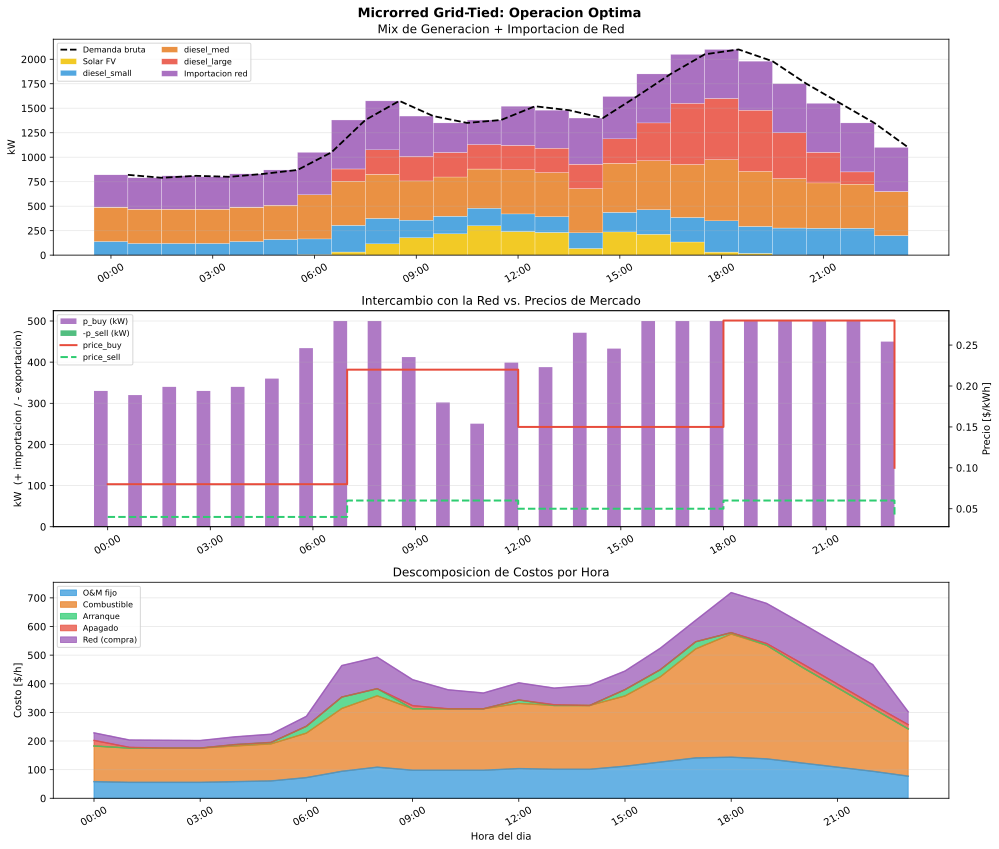

In [36]:
%matplotlib inline
%config InlineBackend.figure_formats = ['svg']
sns.set_palette(sns.color_palette('deep'))

hours     = list(range(24))
dem_vals  = [expected_demand[i] for i in T]
pv_vals   = [pv_output[i]       for i in T]
buy_vals_p  = [price_buy[i]  for i in T]
sell_vals_p = [price_sell[i] for i in T]

fig, axes = plt.subplots(3, 1, figsize=(14, 12))
fig.suptitle('Microrred Grid-Tied: Operacion Optima', fontsize=13, fontweight='bold')

# ── Panel 1: Mix de generacion + importacion ──────────────────────────────────
ax1 = axes[0]
bottoms = np.zeros(24)
gen_colors = {'diesel_small':'#3498db','diesel_med':'#e67e22','diesel_large':'#e74c3c'}

ax1.bar(hours, pv_vals, bottom=bottoms, color='#f1c40f', alpha=0.9,
        label='Solar FV', width=1.0, edgecolor='white', lw=0.3)
bottoms += np.array(pv_vals)

for g in GENERATORS:
    vals = [pe.value(model.output[g,i]) for i in T]
    ax1.bar(hours, vals, bottom=bottoms, color=gen_colors[g],
            alpha=0.85, label=g, width=1.0, edgecolor='white', lw=0.3)
    bottoms += np.array(vals)

ax1.bar(hours, pbuy_vals, bottom=bottoms, color='#9b59b6', alpha=0.85,
        label='Importacion red', width=1.0, edgecolor='white', lw=0.3)

ax1.plot([h+0.5 for h in hours], dem_vals, 'k--', lw=1.8, label='Demanda bruta', zorder=5)
ax1.set_ylabel('kW'); ax1.set_title('Mix de Generacion + Importacion de Red')
ax1.set_xticks(range(0,24,3)); ax1.set_xticklabels([f'{h:02d}:00' for h in range(0,24,3)], rotation=30)
ax1.legend(fontsize=8, loc='upper left', ncol=2); ax1.grid(alpha=0.3, axis='y')

# ── Panel 2: Intercambio con la red y precios ─────────────────────────────────
ax2 = axes[1]; ax2b = ax2.twinx()
x = np.array(hours); w = 0.4
ax2.bar(x-w/2, pbuy_vals,              w, color='#9b59b6', alpha=0.8, label='p_buy (kW)')
ax2.bar(x+w/2, [-v for v in psell_vals], w, color='#27ae60', alpha=0.8, label='-p_sell (kW)')
ax2.axhline(0, color='black', lw=0.8)
ax2b.step(hours, buy_vals_p,  where='post', color='#e74c3c', lw=2,   label='price_buy')
ax2b.step(hours, sell_vals_p, where='post', color='#2ecc71', lw=2, ls='--', label='price_sell')
ax2.set_ylabel('kW  (+ importacion / - exportacion)')
ax2b.set_ylabel('Precio [$/kWh]')
ax2.set_title('Intercambio con la Red vs. Precios de Mercado')
ax2.set_xticks(range(0,24,3)); ax2.set_xticklabels([f'{h:02d}:00' for h in range(0,24,3)], rotation=30)
lines1,lbl1=ax2.get_legend_handles_labels(); lines2,lbl2=ax2b.get_legend_handles_labels()
ax2.legend(lines1+lines2, lbl1+lbl2, fontsize=8, loc='upper left'); ax2.grid(alpha=0.3, axis='y')

# ── Panel 3: Descomposicion de costos por hora ────────────────────────────────
ax3 = axes[2]
period_costs = pd.DataFrame(index=hours)
for component, label in [('cost_fixed ($)','O&M fijo'),('cost_fuel ($)','Combustible'),
                          ('cost_startup ($)','Arranque'),('cost_shutdown ($)','Apagado')]:
    period_costs[label] = solution.groupby('time_period')[component].sum().values
period_costs['Red (compra)'] = [price_buy[i]*pbuy_vals[i] for i in T]
period_costs[['O&M fijo','Combustible','Arranque','Apagado','Red (compra)']].plot.area(
    ax=ax3, alpha=0.75, color=['#3498db','#e67e22','#2ecc71','#e74c3c','#9b59b6'])
ax3.set_xlabel('Hora del dia'); ax3.set_ylabel('Costo [$/h]')
ax3.set_title('Descomposicion de Costos por Hora')
ax3.set_xticks(range(0,24,3)); ax3.set_xticklabels([f'{h:02d}:00' for h in range(0,24,3)], rotation=30)
ax3.legend(fontsize=8, loc='upper left'); ax3.grid(alpha=0.3, axis='y')

plt.tight_layout(); plt.show()

### Mapas de calor generadores activos por clase y periodo

In [37]:
active_matrix = pd.DataFrame(
    index=GENERATORS, columns=[t.strftime('%H:%M') for t in TIME_PERIODS],
    data=[[int(round(pe.value(model.num_active[g,i]))) for i in T] for g in GENERATORS])
output_matrix = pd.DataFrame(
    index=GENERATORS, columns=[t.strftime('%H:%M') for t in TIME_PERIODS],
    data=[[round(pe.value(model.output[g,i]),1) for i in T] for g in GENERATORS])

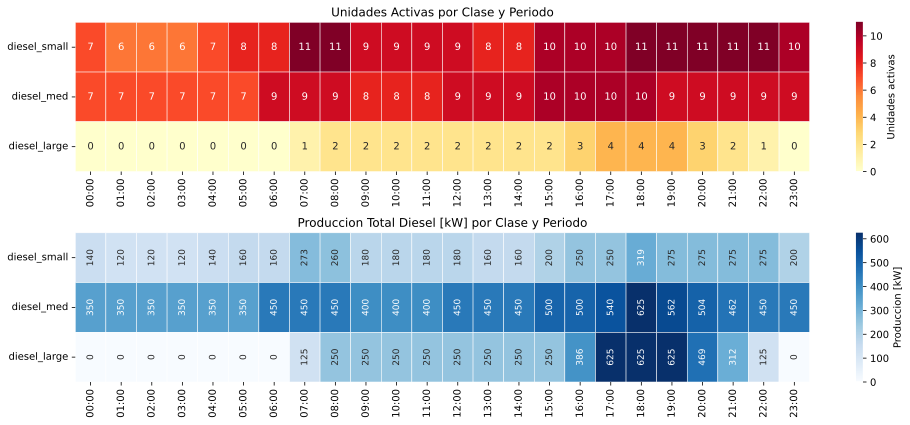

In [38]:
fig, axes = plt.subplots(2,1,figsize=(14,6))
sns.heatmap(active_matrix, annot=True, fmt='d', cmap='YlOrRd',
            linewidths=0.5, cbar_kws={'label':'Unidades activas'}, ax=axes[0])
axes[0].set_title('Unidades Activas por Clase y Periodo')
sns.heatmap(output_matrix, annot=True, fmt='.0f', cmap='Blues',
            linewidths=0.5, cbar_kws={'label':'Produccion [kW]'},
            annot_kws={'size':9,'rotation':90}, ax=axes[1])
axes[1].set_title('Produccion Total Diesel [kW] por Clase y Periodo')
plt.tight_layout(); plt.show()

## Análisis de la Conexión a la Red

Visualización del costo marginal diesel por hora en comparación con los precios de importación, para validar las decisiones del solver.

### Costo marginal vs precios de red

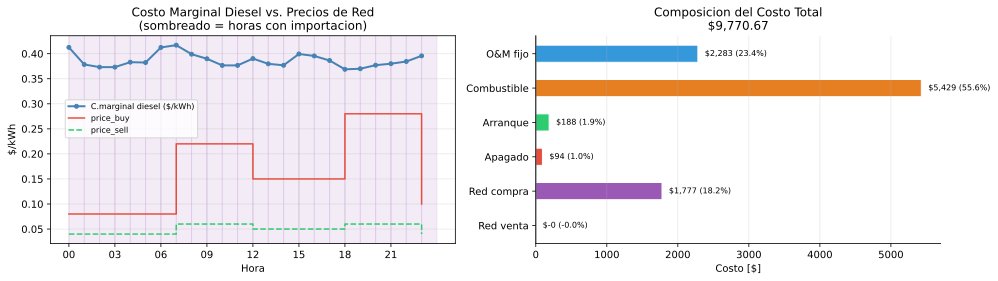

In [39]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# ── Costo marginal horario vs. precios de red ────────────────────────────────
ax1 = axes[0]
diesel_total = [sum(pe.value(model.output[g,i]) for g in GENERATORS) for i in T]
hourly_diesel_cost = [solution.xs(t, level='time_period')['cost_total ($)'].sum()
                      for t in TIME_PERIODS]
costo_marginal = [hourly_diesel_cost[i]/diesel_total[i] if diesel_total[i]>1 else None for i in T]

valid_h = [h for h in hours if costo_marginal[h] is not None]
valid_c = [costo_marginal[h] for h in valid_h]
ax1.plot(valid_h, valid_c, 'steelblue', lw=2, marker='o', ms=4, label='C.marginal diesel ($/kWh)')
ax1.step(hours, buy_vals_p,  where='post', color='#e74c3c', lw=1.5, label='price_buy')
ax1.step(hours, sell_vals_p, where='post', color='#2ecc71', lw=1.5, ls='--', label='price_sell')
for i in T:
    if pbuy_vals[i] > 0.1:
        ax1.axvspan(i, i+1, alpha=0.12, color='#9b59b6')
ax1.set_xlabel('Hora'); ax1.set_ylabel('$/kWh')
ax1.set_title('Costo Marginal Diesel vs. Precios de Red\n(sombreado = horas con importacion)')
ax1.set_xticks(range(0,24,3)); ax1.set_xticklabels([f'{h:02d}' for h in range(0,24,3)])
ax1.legend(loc='center', bbox_to_anchor=(0.2, 0.6), fontsize=8)
ax1.grid(alpha=0.3)

# ── Composicion del costo total ───────────────────────────────────────────────
ax2 = axes[1]
cost_components = {'O&M fijo':c_om_total,'Combustible':c_fuel_total,
                   'Arranque':c_start_total,'Apagado':c_stop_total,
                   'Red compra':total_cost_buy,'Red venta':-total_rev_sell}
colors_bar = ['#3498db','#e67e22','#2ecc71','#e74c3c','#9b59b6','#1abc9c']
labels_c = list(cost_components.keys())
values_c = list(cost_components.values())
bars = ax2.barh(labels_c, values_c, color=colors_bar, edgecolor='white', height=0.5)
for bar, val in zip(bars, values_c):
    pct = 100*val/costo_total
    x_lbl = bar.get_width() + costo_total*0.01 if val>=0 else bar.get_width()-costo_total*0.01
    ha = 'left' if val>=0 else 'right'
    ax2.text(x_lbl, bar.get_y()+bar.get_height()/2,
             f'${val:,.0f} ({pct:.1f}%)', ha=ha, va='center', fontsize=8)
ax2.axvline(0, color='black', lw=0.8)
ax2.set_xlabel('Costo [$]')
ax2.set_title(f'Composicion del Costo Total\n${costo_total:,.2f}')
ax2.invert_yaxis(); ax2.grid(alpha=0.3, axis='x')
ax2.spines[['top','right']].set_visible(False)
plt.tight_layout(); plt.show()

### Arranques y Apagados por Clase de Generador y Período

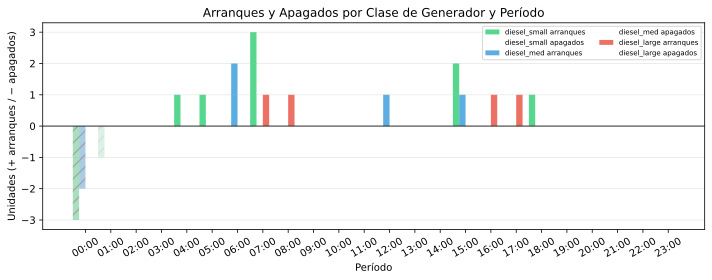

In [40]:
fig, ax = plt.subplots(figsize=(10, 4))
width = 0.25
x = np.arange(len(TIME_PERIODS))
labels = [t.strftime('%H:%M') for t in TIME_PERIODS]
colors_start = ['#2ecc71', '#3498db', '#e74c3c']
colors_stop  = ['#27ae60', '#2980b9', '#c0392b']

for idx, g in enumerate(GENERATORS):
    starts = [int(round(pe.value(model.num_startup[g, i])))  for i in T]
    stops  = [int(round(pe.value(model.num_shutdown[g, i]))) for i in T]
    offset = (idx - 1) * width
    ax.bar(x+offset-width/2, starts,          width, color=colors_start[idx], alpha=0.8, label=f'{g} arranques')
    ax.bar(x+offset-width/2, [-s for s in stops], width, color=colors_stop[idx], alpha=0.4, hatch='//', label=f'{g} apagados')

ax.axhline(0, color='black', linewidth=0.8)
ax.set_xticks(x); ax.set_xticklabels(labels, rotation=30)
ax.set_xlabel("Período"); ax.set_ylabel("Unidades (+ arranques / − apagados)")
ax.set_title("Arranques y Apagados por Clase de Generador y Período")
ax.legend(fontsize=7, ncol=2, loc='upper right')
ax.grid(alpha=0.3, axis='y')
plt.tight_layout(); plt.show()

## Estadísticas por clase de generador

In [41]:
print(f"{'Clase':<14} {'Energía (kWh)':>14} {'Horas activo':>13} {'C. Total ($)':>13} {'$/kWh':>8} {'Factor uso':>11}")
print("-" * 90)
for g in GENERATORS:
    energia  = sum(pe.value(model.output[g, i]) for i in T)
    h_activo = sum(int(round(pe.value(model.num_active[g, i]))) for i in T)
    c_tot    = solution.loc[g, 'cost_total ($)'].sum()
    max_cap  = generator_data.loc[g,'max_output'] * generator_data.loc[g,'num_available']
    f_uso    = energia / (max_cap * 24)
    print(f"{g:<14} {energia:>14.0f} {h_activo:>13d} {c_tot:>13.2f} {c_tot/energia if energia>0 else 0:>8.4f} {f_uso:>11.3f}")

Clase           Energía (kWh)  Horas activo  C. Total ($)    $/kWh  Factor uso
------------------------------------------------------------------------------------------
diesel_small             4851           217       1800.07   0.3711       0.421
diesel_med              10594           205       4036.10   0.3810       0.441
diesel_large             5293            38       2157.17   0.4076       0.176


## Estadísticas globales

In [42]:
print(f'   Costo total optimo   : ${costo_total:,.2f}')
total_starts = sum(int(round(pe.value(model.num_startup[g,i])))  for g in GENERATORS for i in T)
total_stops  = sum(int(round(pe.value(model.num_shutdown[g,i]))) for g in GENERATORS for i in T)
print(f'   Total arranques      : {total_starts}')
print(f'   Total apagados       : {total_stops}')

   Costo total optimo   : $9,770.67
   Total arranques      : 16
   Total apagados       : 16


In [43]:
e_diesel = sum(pe.value(model.output[g,i]) for g in GENERATORS for i in T)
e_pv     = sum(pv_output.values())
e_buy    = sum(pbuy_vals)
e_sell   = sum(psell_vals)
e_total  = sum(expected_demand.values())
print('-- Energia por fuente -----------------------------------------')
print(f'   Diesel               : {e_diesel:>8.1f} kWh  ({100*e_diesel/e_total:.1f}%)')
print(f'   Solar FV             : {e_pv:>8.1f} kWh  ({100*e_pv/e_total:.1f}%)')
print(f'   Importado de red     : {e_buy:>8.1f} kWh  ({100*e_buy/e_total:.1f}%)')
print(f'   Exportado a red      : {e_sell:>8.1f} kWh')
print(f'   Demanda total        : {e_total:>8.0f} kWh')

-- Energia por fuente -----------------------------------------
   Diesel               :  20737.9 kWh  (63.2%)
   Solar FV             :   2026.5 kWh  (6.2%)
   Importado de red     :  10060.5 kWh  (30.6%)
   Exportado a red      :      0.0 kWh
   Demanda total        :    32825 kWh


In [44]:
print('-- Costos de red ----------------------------------------------')
print(f'   Costo importacion    : ${total_cost_buy:>8.2f}')
print(f'   Ingreso exportacion  : ${total_rev_sell:>8.2f}')
print(f'   Costo neto red       : ${c_grid_net:>8.2f}  ({100*c_grid_net/costo_total:.1f}% del total)')

-- Costos de red ----------------------------------------------
   Costo importacion    : $ 1777.34
   Ingreso exportacion  : $    0.00
   Costo neto red       : $ 1777.34  (18.2% del total)


In [45]:
print('-- Horas con importacion (p_buy > 0) --------------------------')
horas_compra = [(i, pbuy_vals[i], price_buy[i]) for i in T if pbuy_vals[i]>0.1]
for h, pb, pr in horas_compra:
    print(f'   h={h:02d}  p_buy={pb:>6.1f} kW  price_buy=${pr:.2f}/kWh')

-- Horas con importacion (p_buy > 0) --------------------------
   h=00  p_buy= 330.0 kW  price_buy=$0.08/kWh
   h=01  p_buy= 320.0 kW  price_buy=$0.08/kWh
   h=02  p_buy= 340.0 kW  price_buy=$0.08/kWh
   h=03  p_buy= 330.0 kW  price_buy=$0.08/kWh
   h=04  p_buy= 340.0 kW  price_buy=$0.08/kWh
   h=05  p_buy= 360.0 kW  price_buy=$0.08/kWh
   h=06  p_buy= 434.2 kW  price_buy=$0.08/kWh
   h=07  p_buy= 500.0 kW  price_buy=$0.22/kWh
   h=08  p_buy= 500.0 kW  price_buy=$0.22/kWh
   h=09  p_buy= 412.4 kW  price_buy=$0.22/kWh
   h=10  p_buy= 302.0 kW  price_buy=$0.22/kWh
   h=11  p_buy= 250.6 kW  price_buy=$0.22/kWh
   h=12  p_buy= 399.0 kW  price_buy=$0.15/kWh
   h=13  p_buy= 388.0 kW  price_buy=$0.15/kWh
   h=14  p_buy= 471.6 kW  price_buy=$0.15/kWh
   h=15  p_buy= 432.9 kW  price_buy=$0.15/kWh
   h=16  p_buy= 500.0 kW  price_buy=$0.15/kWh
   h=17  p_buy= 500.0 kW  price_buy=$0.15/kWh
   h=18  p_buy= 500.0 kW  price_buy=$0.28/kWh
   h=19  p_buy= 500.0 kW  price_buy=$0.28/kWh
   h=20  p_buy= 

In [46]:
print('-- Horas con exportacion (p_sell > 0) -------------------------')
horas_venta = [(i, psell_vals[i], price_sell[i]) for i in T if psell_vals[i]>0.1]
if horas_venta:
    for h, ps, pr in horas_venta:
        print(f'   h={h:02d}  p_sell={ps:>6.1f} kW  price_sell=${pr:.2f}/kWh')
else:
    print('   (ninguna — como se esperaba con 400 kWp y demanda > 790 kW)')

-- Horas con exportacion (p_sell > 0) -------------------------
   (ninguna — como se esperaba con 400 kWp y demanda > 790 kW)


## Conclusiones

Este modelo implementa un Unit Commitment + Despacho Económico + Conexión a la Red para una microrred diesel-FV operando en modo *grid-tied*:

1. Variables de intercambio: `p_buy[t]` y `p_sell[t]` (continuas, acotadas por `pcc_limit = 500 kW`) representan la potencia importada y exportada en cada período.

2. Variable de no-simultaneidad: `is_buying[t]` (binaria) garantiza mediante formulación Big-M que en cada período el sistema sea netamente importador *o* exportador, nunca ambos.

3. Balance de energía modificado: se usa la demanda bruta explícitamente:
$$\sum_g P^{\mathrm{D}}_{g,t} + P^{\mathrm{PV}}_t + p^{\mathrm{buy}}_t - p^{\mathrm{sell}}_t = D_t$$

4. Reserva operativa desacoplada de la red: la restricción de reserva (spinning reserve 15%) se mantiene sobre capacidad diesel exclusivamente, modelando el requerimiento de operación en isla ante desconexión de la red.

5. Función objetivo ampliada: incluye el costo neto de intercambio $\sum_t (\pi^{\mathrm{buy}}_t \cdot p^{\mathrm{buy}}_t - \pi^{\mathrm{sell}}_t \cdot p^{\mathrm{sell}}_t)$.

Comportamiento esperado del solver:

- Horas valle (00–06, $0.08/kWh): el precio de compra es menor que el costo marginal diesel (~$0.22/kWh) → el solver importa de la red y reduce el despacho diesel al mínimo técnico compatible con la reserva de isla.
- Horas pico tarde (18–22, $0.28/kWh): el precio de compra supera el costo marginal diesel → preferencia por generación propia.
- Exportación FV: no ocurre porque la demanda mínima (790 kW) siempre supera la producción FV máxima (~300 kW).
- Sin almacenamiento: el sistema no puede trasladar energía barata de un período a otro. Este es el principal incentivo para incorporar baterías en una versión futura (V7 o posterior).